# Lecture 10: Exponential Smoothing

*DASCI 270 - Time Series Analysis*

*Prepared by Sebastian C. Ibañez, PhD*

*Based on [FPPY Chapter 8](https://otexts.com/fpppy/nbs/08-exponential-smoothing.html)*

`The best way to predict the future is to create it. -Abraham Lincoln`

In [1]:
%%capture
!pip install statsforecast
!pip install utilsforecast

!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/algeria_exports.csv' -P ./data/
!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/aus_economy.csv' -P ./data/
!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/www_usage.csv' -P ./data/
!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/tourism.csv' -P ./data/
!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/pedestrian.csv' -P ./data/

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
})

pd.set_option("display.precision", 4)
np.set_printoptions(suppress=True)

## Simple exponential smoothing

The **simple exponential smoothing** (SES) method produces one-step ahead forecasts of the form:

\begin{align*}
    \hat{y}_{T+1} &= \alpha y_{T} + \alpha(1-\alpha) y_{T-1} + \alpha(1-\alpha)^2 y_{T-2} + \cdots
\end{align*}

where $0 \leq \alpha \leq 1$ is a smoothing parameter. In this formulation, the forecast is an exponentially decaying weighted average of all the observations in the series $y_1, \ldots, y_T$.

For illustration, the table below shows the weights attached to observations for four different values of $\alpha$:

In [5]:
alpha_levels = [0.2, 0.4, 0.6, 0.8]
lag = 6

weights = {}
for a in alpha_levels:
    weights[f'a={a}'] = []
    for i in range(lag):
        weights[f'a={a}'].append(a*(1-a)**i)

df_weights = pd.DataFrame.from_dict(weights)
df_weights.index = [f'y(T-{i})' for i in range(lag)]
df_weights.round(4)

,a=0.2,a=0.4,a=0.6,a=0.8
y(T-0),0.2000,0.4000,0.6000,0.8000
y(T-1),0.1600,0.2400,0.2400,0.1600
y(T-2),0.1280,0.1440,0.0960,0.0320
y(T-3),0.1024,0.0864,0.0384,0.0064
y(T-4),0.0819,0.0518,0.0154,0.0013
y(T-5),0.0655,0.0311,0.0061,0.0003


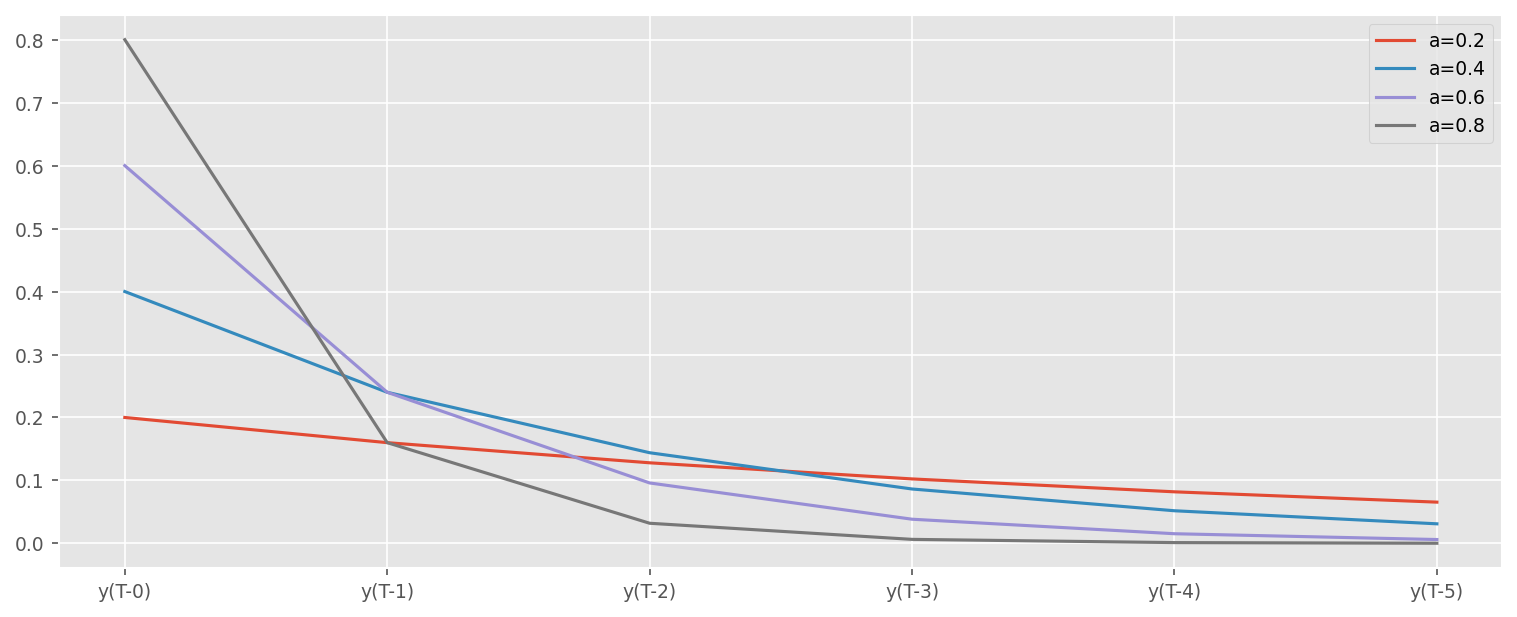

In [6]:
df_weights.plot()
plt.show()

Essentially, as $\alpha \rightarrow 1$ more weight is given to the present and as $\alpha \rightarrow 0$ more weight is spread out to the past.

### Example: Algerian exports

In this example, simple exponential smoothing is applied to forecast exports of goods and services from Algeria.

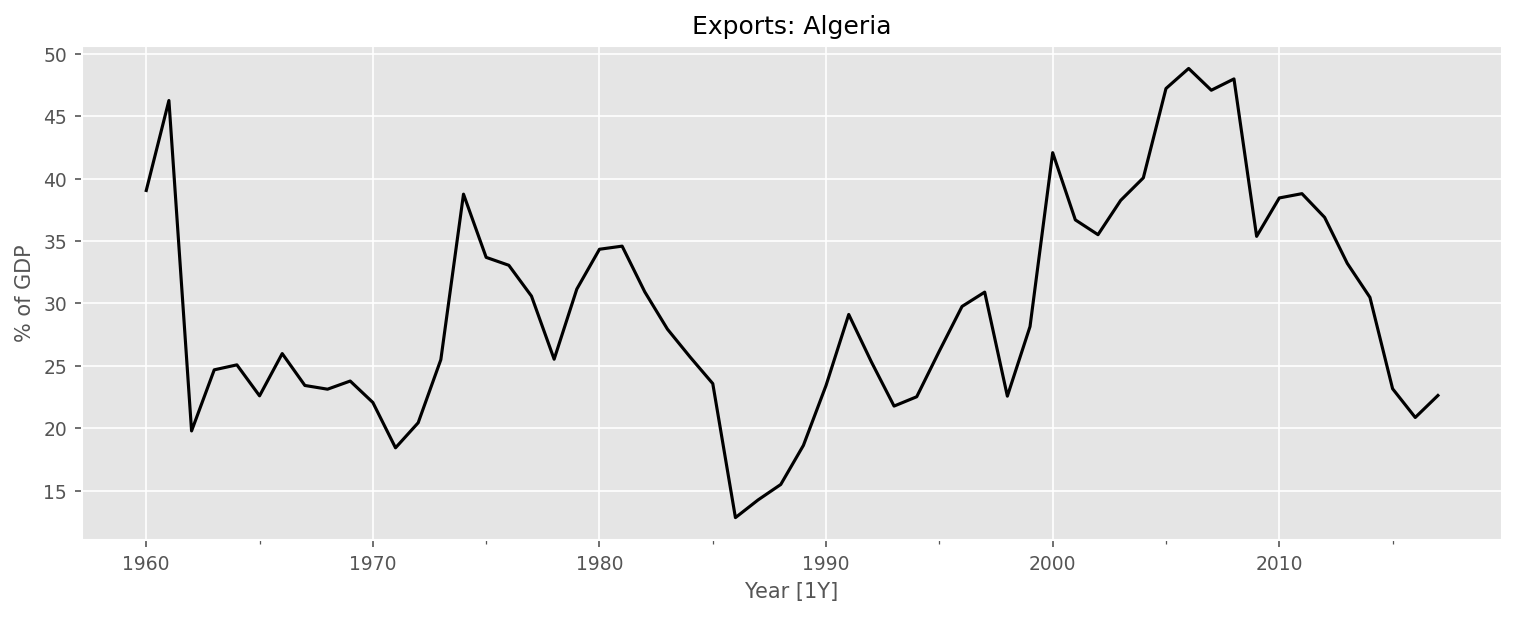

,unique_id,ds,y
0,Algeria,1960-12-31,39.0432
1,Algeria,1961-12-31,46.2446
2,Algeria,1962-12-31,19.7939
3,Algeria,1963-12-31,24.6847
4,Algeria,1964-12-31,25.0841


In [7]:
df_algeria = pd.read_csv("data/algeria_exports.csv", parse_dates=["ds"])

fig, ax = plt.subplots()
df_algeria.plot(ax=ax, x='ds', y='y', color='black', legend=False)
ax.set_title("Exports: Algeria")
ax.set_xlabel("Year [1Y]")
ax.set_ylabel("% of GDP")
plt.autoscale()
plt.show()

df_algeria.head()

alpha = 0.2000 ; l_0 = 39.04
alpha = 0.4000 ; l_0 = 39.04
alpha = 0.6000 ; l_0 = 39.04
alpha = 0.8000 ; l_0 = 39.04


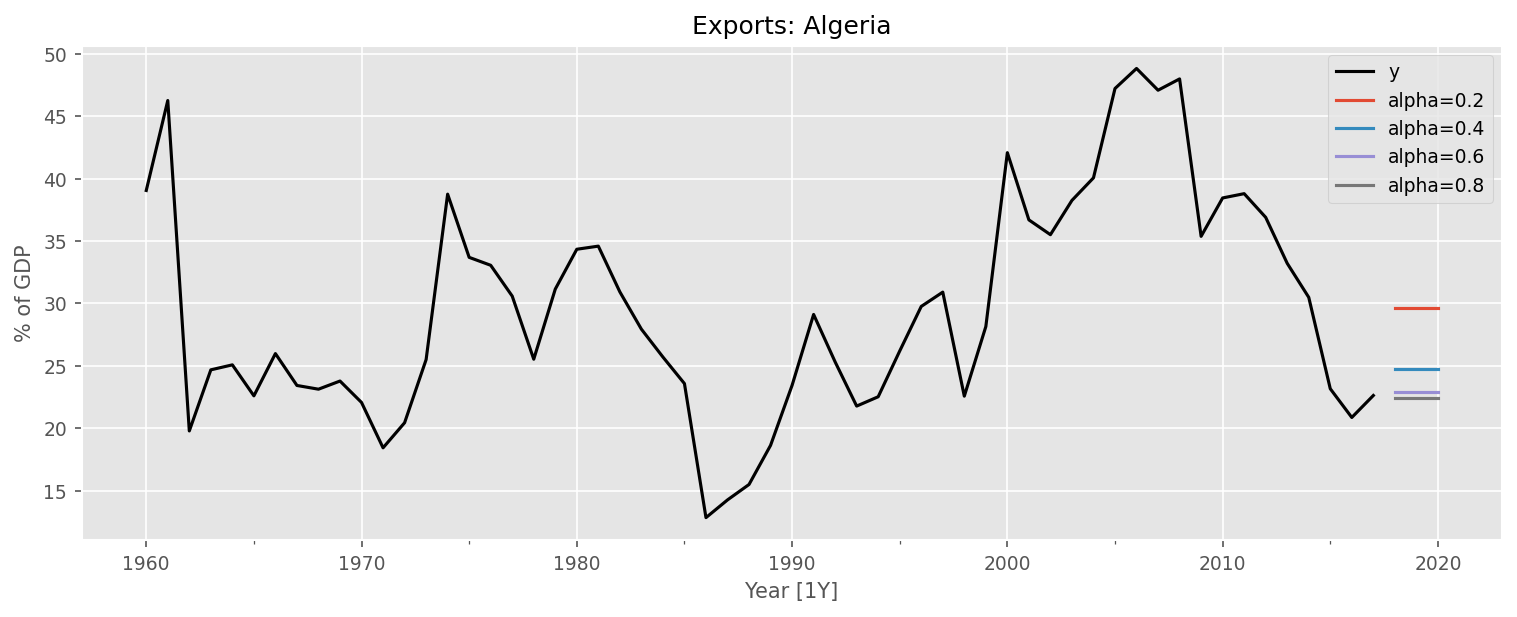

In [12]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

alpha_levels = [0.2, 0.4, 0.6, 0.8]

df = df_algeria['y']
df.index = pd.date_range(start=str(df_algeria['ds'].iloc[0].year), end=str(df_algeria['ds'].iloc[-1].year + 1), freq="YE") # fix dates

ax = df.plot(color='black')

for a in alpha_levels:
    model = SimpleExpSmoothing(df).fit(smoothing_level=a, optimized=False) # use SimpleExpSmoothing if you want to set alpha manually
    forecast = model.forecast(3).rename(f'alpha={a}')
    print(f'alpha = {model.params["smoothing_level"]:.4f} ; l_0 = {model.params["initial_level"]:.2f}')
    forecast.plot()

ax.set_title("Exports: Algeria")
ax.set_xlabel("Year [1Y]")
ax.set_ylabel("% of GDP")
plt.legend()
plt.autoscale()
plt.show()

### SES Parameters

Notice that we can re-write the SES equation above in terms of fitted values and in recursive form:

\begin{align*}
    \hat{y}_{t+1} &= \alpha y_{t} + (1-\alpha) \hat{y}_{t}
\end{align*}

where $t = 1, 2, \ldots, T$.

Since the process has to start from somewhere, we can write the very first SES forecast as:

\begin{align*}
    \hat{y}_{2} &= \alpha y_{1} + (1-\alpha) \hat{y}_{1} \\
    &= \alpha y_{1} + (1-\alpha) \ell_0
\end{align*}

Since there are no values before $y_1$, we can treat $\hat{y}_{1} = \ell_0$ as a parameter.

In summary, the SES method has two parameters: the <b><i>smoothing parameter</b></i> $\alpha$ and the <b><i>initial level</b></i> $\ell_0$.

These parameters can either be set manually or optimized. In the case of optimization, we can treat the parameter estimation as a curve-fitting problem and minimize the sum of squared errors (SSE) of the one-step training errors.

alpha = 0.8389 ; l_0 = 39.54


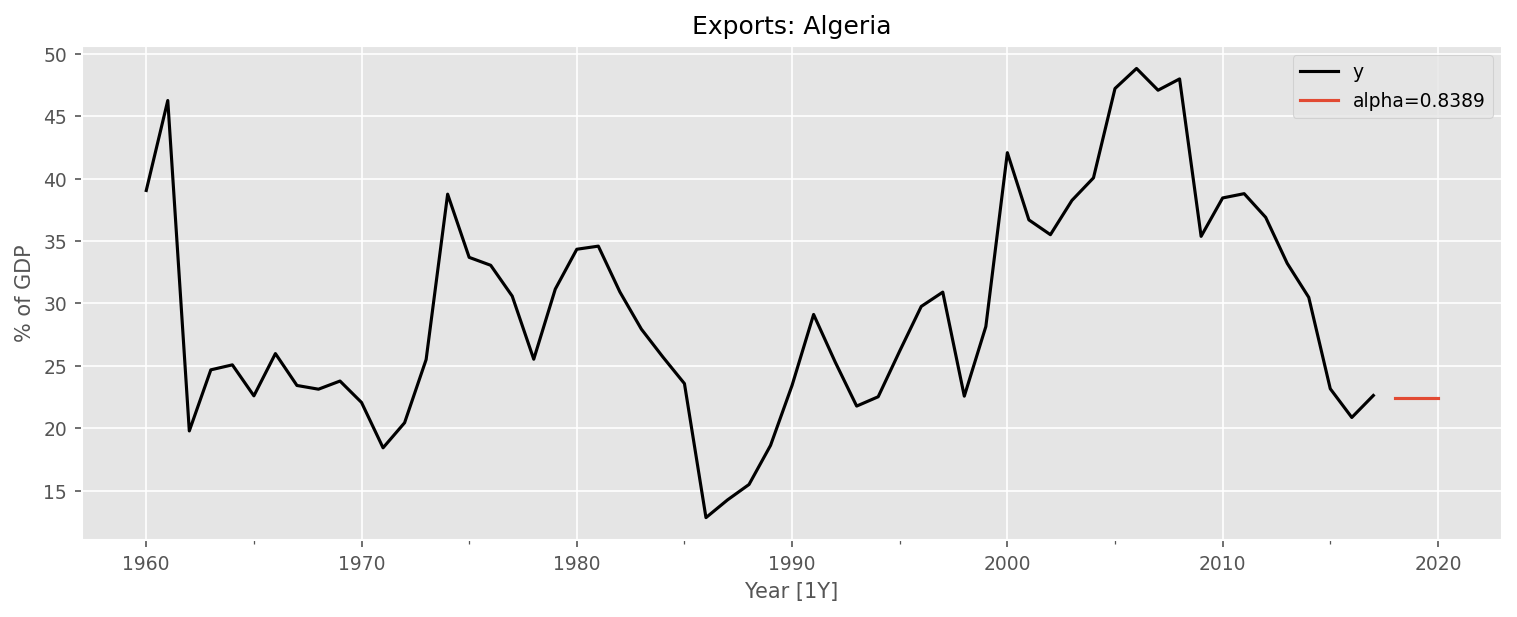

2018-12-31    22.4413
2019-12-31    22.4413
2020-12-31    22.4413
Freq: YE-DEC, Name: alpha=0.8389, dtype: float64

In [13]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ax = df.plot(color='black')

model = ExponentialSmoothing(df).fit(optimized=True) # use ExponentialSmoothing in general!
forecast = model.forecast(3).rename(f'alpha={model.params["smoothing_level"]:.4f}')

print(f'alpha = {model.params["smoothing_level"]:.4f} ; l_0 = {model.params["initial_level"]:.2f}')
forecast.plot()

ax.set_title("Exports: Algeria")
ax.set_xlabel("Year [1Y]")
ax.set_ylabel("% of GDP")
plt.legend()
plt.autoscale()
plt.show()

forecast

In [14]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, SimpleExponentialSmoothingOptimized

sf = StatsForecast(models=[SimpleExponentialSmoothingOptimized(alias="SES")], freq="YE")

df_f = sf.forecast(df=df_algeria, h=3, fitted=True)
df_f.head()

,unique_id,ds,SES
0,Algeria,2018-12-31,22.4412
1,Algeria,2019-12-31,22.4412
2,Algeria,2020-12-31,22.4412


In [ ]:
sf = StatsForecast(models=[AutoETS(season_length=1, model="ANN", alias="SES")], freq="YE") # the same as SES. "ANN" = additive errors, no trend, no seasonality
#StatsForecast throws the model parameters


df_f = sf.forecast(df=df_algeria, h=3, fitted=True)
df_f.head()

,unique_id,ds,SES
0,Algeria,2018-12-31,22.4417
1,Algeria,2019-12-31,22.4417
2,Algeria,2020-12-31,22.4417


In [ ]:
ses = AutoETS(season_length=1, model="ANN", alias="SES") # need to fit each model manually to extract optimal params
#ANN - Additive errors, no trend, no seasonality

ses = ses.fit(y=df_algeria["y"].values)

params = np.round(ses.model_["fit"][0], 4)
print("Optimal parameters:")
print("alpha:", params[0])
print("Initial level:", params[1])

Optimal parameters:
alpha: 0.8401
Initial level: 39.53


### Weighted Average Form

\begin{align*}
    \hat{y}_{T+1} &= \sum_{j=0}^{T-1} \alpha(1-\alpha)^j y_{T-j} + (1-\alpha)^T\ell_0
\end{align*}

### Component Form

\begin{align*}
    \text{Forecast Equation:} && \hat{y}_{t+1} &= \ell_t \\
    \text{Smoothing/Level Equation:} && \ell_t &= \alpha y_t + (1-\alpha) \ell_{t-1}
\end{align*}

$\ell_t$ is called the level term. You can think of it as the "average level" of the series.

## Methods with trend


### Holt's Linear Trend Method

\begin{align*}
    \text{Forecast Equation:} && \hat{y}_{t+h} &= \ell_t + hb_t \\
    \text{Level Equation:} && \ell_t &= \alpha y_t + (1-\alpha) (\ell_{t-1} + b_{t-1}) \\
    \text{Trend Equation:} && b_t &= \beta^* (\ell_{t} - \ell_{t-1}) + (1 - \beta^*)b_{t-1}
\end{align*}

where $\ell_t$ denotes an estimate of the level of the series, $b_t$ denotes an estimate of the trend (or slope) of the series, $0 \leq \alpha \leq 1$ is the smoothing parameter for the level, and $0 \leq \beta^* \leq 1$ is the smoothing parameter for the trend.

We note that $\beta^*$ is used instead of $\beta$ because the latter is reserved for a more general form of this model.

### Example: Australian population

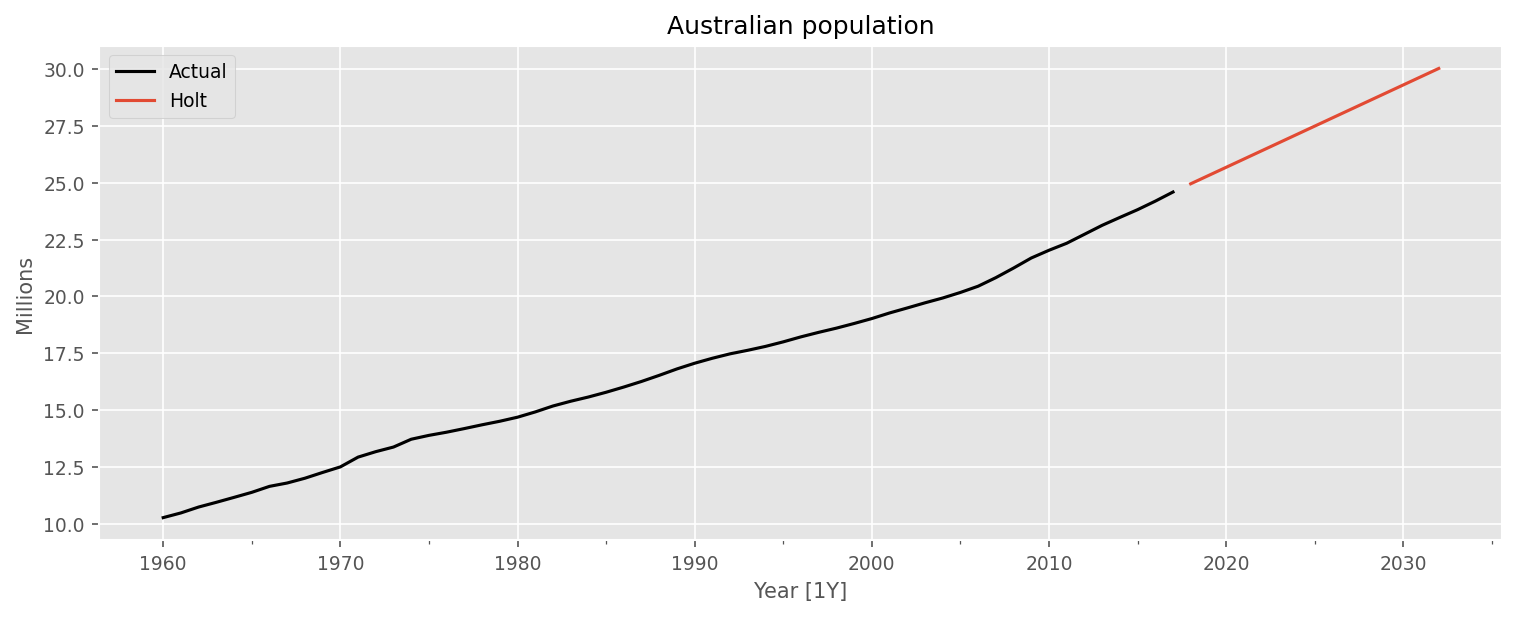

In [17]:
df_aus = pd.read_csv("data/aus_economy.csv", parse_dates=["ds"])
df_aus["y"] = df_aus["y"] / 1e6

sf = StatsForecast(models=[AutoETS(season_length=1, model="AAN", alias="Holt")], freq="YE")

df_f = sf.forecast(df=df_aus, h=15)

fig, ax = plt.subplots()
df_aus.plot(ax=ax, x='ds', y='y', color='black', legend=False)
df_f.plot(ax=ax, x='ds', y='Holt', legend=False)
ax.set_title("Australian population")
ax.set_xlabel("Year [1Y]")
ax.set_ylabel("Millions")
plt.legend(['Actual', 'Holt'])
plt.autoscale()
plt.show()

In [12]:
autoets = AutoETS(season_length=1, model="AAN", alias="Holt")
autoets = autoets.fit(y=df_aus["y"].values)

params = np.round(autoets.model_["fit"][0], 4)
print("Optimal parameters:")
print("alpha:", params[0])
print("beta:", params[1])
print("Initial level:", params[2])
print("Initial trend:", params[3])

Optimal parameters:
alpha: 0.9999
beta: 0.2001
Initial level: 10.0509
Initial trend: 0.2264


### Damped Trend Method

\begin{align*}
    \text{Forecast Equation:} && \hat{y}_{t+h} &= \ell_t + (\phi + \phi^2 + \ldots + \phi^h)b_t \\
    \text{Level Equation:} && \ell_t &= \alpha y_t + (1-\alpha) (\ell_{t-1} + \phi b_{t-1}) \\
    \text{Trend Equation:} && b_t &= \beta^* (\ell_{t} - \ell_{t-1}) + (1 - \beta^*)\phi b_{t-1}
\end{align*}

where $0 < \phi < 1$ is a damping parameter. If $\phi = 1$, the method is identical to Holt's linear trend method. Else, $\phi$ dampens the trend so that it approaches a constant some time in the future.

In practice, we usually restrict $\phi$ to be somewhere between a minimum of $0.8$ and $0.98$ as the damping has a very strong effect for smaller values and the model becomes indistinguishable from a non-damped model as $\phi \rightarrow 1$.

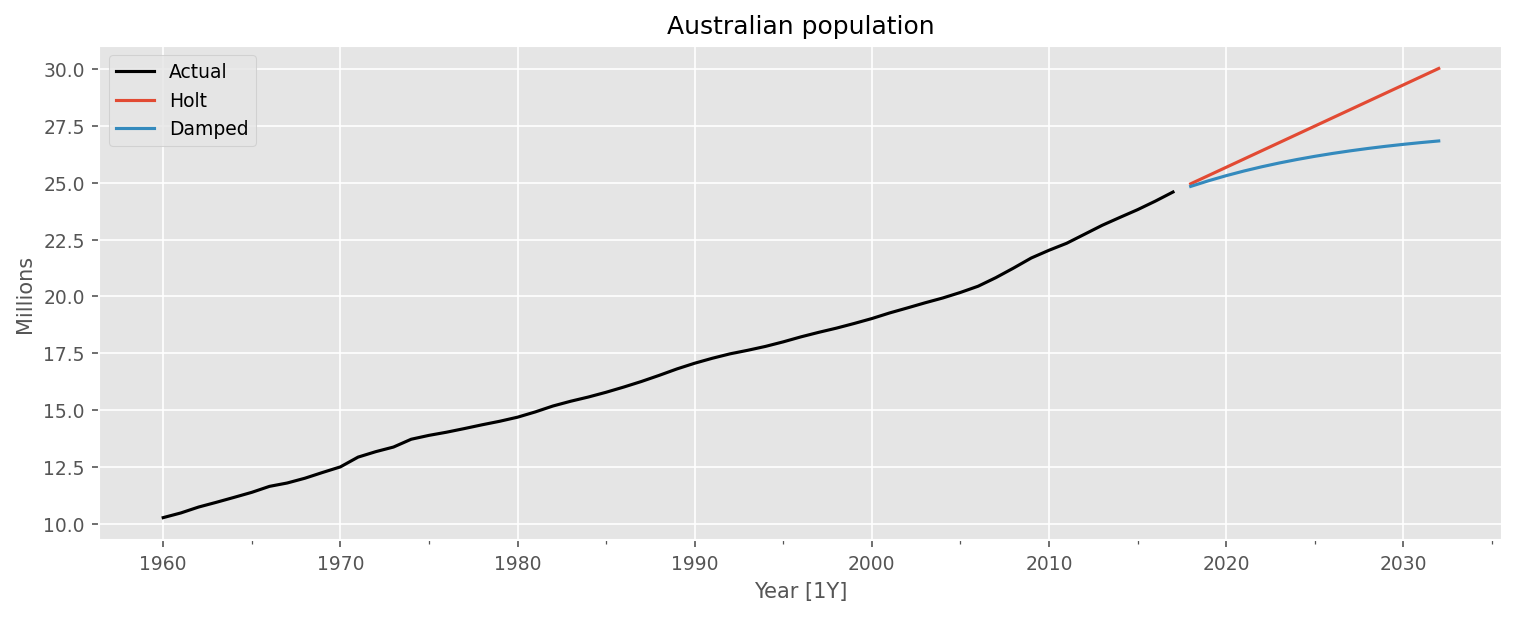

In [32]:
sf = StatsForecast(models=[AutoETS(season_length=1, model="AAN", alias="Holt"), AutoETS(season_length=1, model="AAN", damped=True, phi=0.94, alias="Damped")], freq="YE")

df_f = sf.forecast(df=df_aus, h=15)

fig, ax = plt.subplots()
df_aus.plot(ax=ax, x='ds', y='y', color='black', legend=False)
df_f.plot(ax=ax, x='ds', y='Holt', legend=False)
df_f.plot(ax=ax, x='ds', y='Damped', legend=False)
ax.set_title("Australian population")
ax.set_xlabel("Year [1Y]")
ax.set_ylabel("Millions")
plt.legend(['Actual', 'Holt', 'Damped'])
plt.autoscale()
plt.show()

### Example: Internet usage

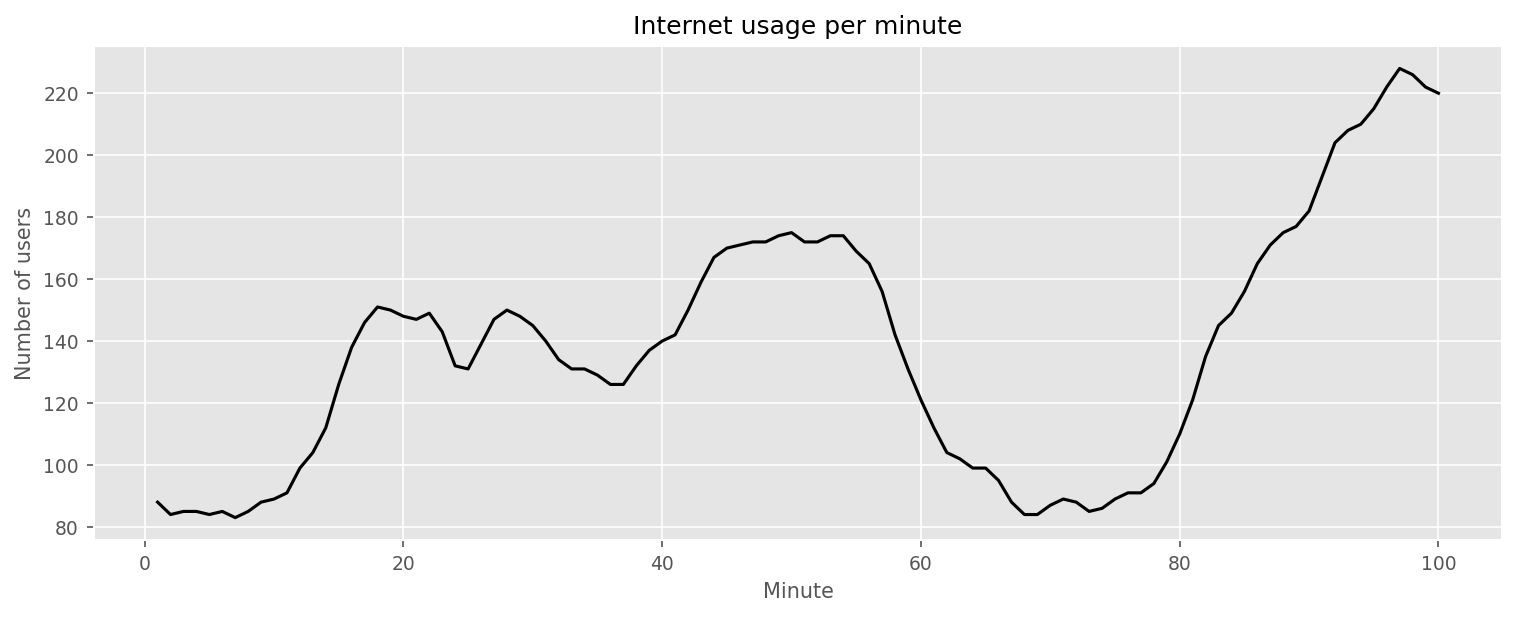

In [18]:
df_www = pd.read_csv("data/www_usage.csv")

fig, ax = plt.subplots()
df_www.plot(ax=ax, x='ds', y='y', color='black', legend=False)
ax.set_title("Internet usage per minute")
ax.set_xlabel("Minute")
ax.set_ylabel("Number of users")
plt.autoscale()
plt.show()

In [30]:
from functools import partial
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mase, mape as _mape

sf = StatsForecast(
    models=[
        AutoETS(season_length=1, model="ANN", alias="SES"),
        AutoETS(season_length=1, model="AAN", alias="Holt"),
        AutoETS(season_length=1, model="AAN", damped=True, phi=0.9, alias="Damped"),
    ],
    freq=1,
)

df_f = sf.cross_validation(df=df_www, h=10, n_windows=10, step_size=1) # one-step rolling window forecasts

def mape(df, models, id_col = "unique_id", target_col = "y"):
    df_mape = _mape(df, models, id_col=id_col, target_col=target_col)
    df_mape.loc[:, df_mape.select_dtypes(include='number').columns] *= 100
    return df_mape

df_eval = evaluate(df_f.drop("cutoff", axis=1), metrics=[mae, rmse, mape, partial(mase, seasonality=1)], train_df=df_www)
df_eval.set_index('metric').T.drop('unique_id').sort_values(by='mae')

metric,mae,rmse,mape,mase
Damped,12.1891,17.6328,6.4149,2.6936
Holt,14.2958,17.8485,7.2893,3.1591
SES,34.2007,38.2368,17.4301,7.5577


In [34]:
df_f

,unique_id,ds,cutoff,y,SES,Holt,Damped
0,www_usage,82,81,135.0,120.9989,124.3255,124.5149
1,www_usage,83,81,145.0,120.9989,127.6519,128.0307
2,www_usage,84,81,149.0,120.9989,130.3130,130.9332
3,www_usage,85,81,156.0,120.9989,132.4418,133.3293
4,www_usage,86,81,165.0,120.9989,134.1449,135.3076
...,...,...,...,...,...,...,...
95,www_usage,96,90,222.0,181.9995,199.1962,191.5017
96,www_usage,97,90,228.0,181.9995,201.2209,192.2325
97,www_usage,98,90,226.0,181.9995,203.0511,192.8208
98,www_usage,99,90,222.0,181.9995,204.7057,193.2944


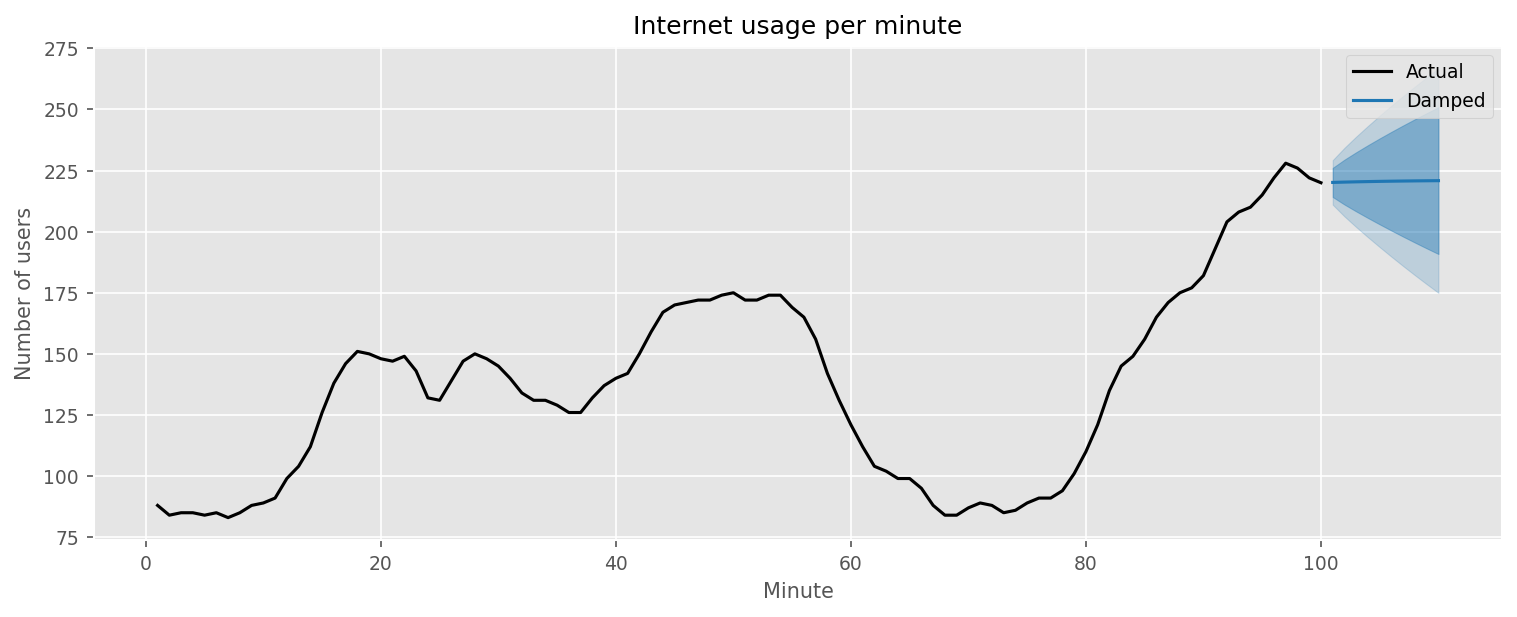

In [22]:
df_f = sf.forecast(df=df_www, h=10, level=[80, 95])

fig, ax = plt.subplots()
df_www.plot(ax=ax, x='ds', y='y', color='black', legend=False)
df_f.plot(ax=ax, x='ds', y='Damped', color='tab:blue', legend=False)
ax.fill_between(df_f["ds"], df_f['Damped-lo-95'], df_f['Damped-hi-95'], color='tab:blue', alpha = 0.2)
ax.fill_between(df_f["ds"], df_f['Damped-lo-80'], df_f['Damped-hi-80'], color='tab:blue', alpha = 0.4)
ax.set_title("Internet usage per minute")
ax.set_xlabel("Minute")
ax.set_ylabel("Number of users")
plt.legend(['Actual', 'Damped'])
plt.autoscale()
plt.show()

## Methods with seasonality

### Holt-Winters' Method

#### Additive Version

\begin{align*}
    \text{Forecast Equation:} && \hat{y}_{t+h} &= \ell_t + hb_t + s_{t+h-m(k+1)} \\
    \text{Level Equation:} && \ell_t &= \alpha (y_t - s_{t-m}) + (1-\alpha) (\ell_{t-1} + b_{t-1}) \\
    \text{Trend Equation:} && b_t &= \beta^* (\ell_{t} - \ell_{t-1}) + (1 - \beta^*)b_{t-1} \\
    \text{Seasonal Equation:} && s_t &= \gamma (y_t - \ell_{t-1} - b_{t-1}) + (1 - \gamma)s_{t-m} \\
\end{align*}

where $k$ is the integer part of $(h-1)/m$, which ensures that the estimates of the seasonal indices used for forecasting come from the final year of the sample. Similar to the formulations above, the new parameter $0 \leq \gamma \leq 1-\alpha$ is the smoothing parameter for the seasonal component.

#### Multiplicative Version

\begin{align*}
    \text{Forecast Equation:} && \hat{y}_{t+h} &= (\ell_t + hb_t)s_{t+h-m(k+1)} \\
    \text{Level Equation:} && \ell_t &= \alpha \frac{y_t}{s_{t-m}} + (1-\alpha) (\ell_{t-1} + b_{t-1}) \\
    \text{Trend Equation:} && b_t &= \beta^* (\ell_{t} - \ell_{t-1}) + (1 - \beta^*)b_{t-1} \\
    \text{Seasonal Equation:} && s_t &= \gamma \frac{y_t}{(\ell_{t-1} + b_{t-1})} + (1 - \gamma)s_{t-m} \\
\end{align*}

#### Damped Multiplicative Version

\begin{align*}
    \text{Forecast Equation:} && \hat{y}_{t+h} &= [\ell_t + (\phi + \phi^2 + \ldots + \phi^h)b_t]s_{t+h-m(k+1)} \\
    \text{Level Equation:} && \ell_t &= \alpha \frac{y_t}{s_{t-m}} + (1-\alpha) (\ell_{t-1} + \phi b_{t-1}) \\
    \text{Trend Equation:} && b_t &= \beta^* (\ell_{t} - \ell_{t-1}) + (1 - \beta^*)\phi b_{t-1} \\
    \text{Seasonal Equation:} && s_t &= \gamma \frac{y_t}{(\ell_{t-1} + \phi b_{t-1})} + (1 - \gamma)s_{t-m} \\
\end{align*}

Note that an damped additive version also exists but is omitted for brevity.

### Example: Domestic overnight trips in Australia

In [24]:
df_tourism = pd.read_csv("data/tourism.csv", parse_dates=["ds"])

df_holidays = (
    df_tourism.query('Purpose == "Holiday"')
    .groupby(["Purpose", "ds"], as_index=False)["y"]
    .sum()
)
df_holidays["y"] = df_holidays["y"] / 1e3
df_holidays.rename(columns={"Purpose": "unique_id"}, inplace=True)
df_holidays

,unique_id,ds,y
0,Holiday,1998-01-01,11.8060
1,Holiday,1998-04-01,9.2757
2,Holiday,1998-07-01,8.6425
3,Holiday,1998-10-01,9.2995
4,Holiday,1999-01-01,11.1720
...,...,...,...
75,Holiday,2016-10-01,10.0850
76,Holiday,2017-01-01,12.4064
77,Holiday,2017-04-01,10.4712
78,Holiday,2017-07-01,10.4992


In [27]:
sf = StatsForecast(
    models=[
        AutoETS(season_length=4, model="AAA", alias="additive"),
        AutoETS(season_length=4, model="MAM", alias="multiplicative"),
    ],
    freq="QS",
)

df_f = sf.forecast(df=df_holidays, h=12, fitted=True)
df_f

,unique_id,ds,additive,multiplicative
0,Holiday,2018-01-01,12.9220,13.2796
1,Holiday,2018-04-01,11.1960,11.1868
2,Holiday,2018-07-01,10.9239,10.8066
3,Holiday,2018-10-01,11.1912,11.1073
4,Holiday,2019-01-01,13.3794,13.8201
5,Holiday,2019-04-01,11.6534,11.6376
6,Holiday,2019-07-01,11.3813,11.2377
7,Holiday,2019-10-01,11.6486,11.5460
8,Holiday,2020-01-01,13.8368,14.3607
9,Holiday,2020-04-01,12.1108,12.0883


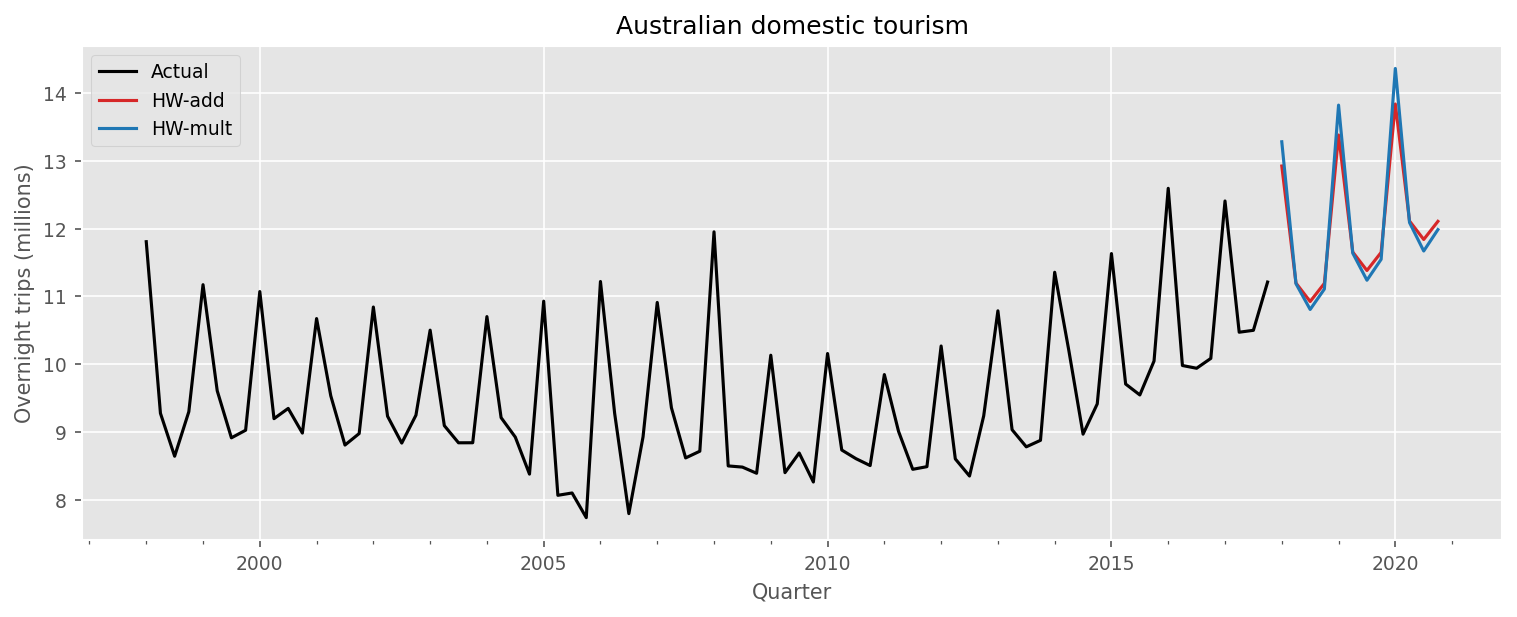

In [28]:
fig, ax = plt.subplots()
df_holidays.plot(ax=ax, x='ds', y='y', color='black', legend=False)
df_f.plot(ax=ax, x='ds', y='additive', color='tab:red', legend=False)
df_f.plot(ax=ax, x='ds', y='multiplicative', color='tab:blue', legend=False)
ax.set_title("Australian domestic tourism")
ax.set_xlabel("Quarter")
ax.set_ylabel("Overnight trips (millions)")
plt.legend(['Actual', 'HW-add', 'HW-mult'])
plt.autoscale()
plt.show()

### Example: Daily pedestrian traffic

In [35]:
df_ped = pd.read_csv("data/pedestrian.csv", parse_dates=["ds"])

df_scross = (
    df_ped.query(
        'ds >= "2016-07-01" and ds <= "2016-07-31" and unique_id == "Southern Cross Station"'
    )
    .groupby(["unique_id", "ds"], as_index=False)["y"]
    .sum()
)
df_scross["y"] = df_scross["y"] / 1000

sf = StatsForecast(
    models=[AutoETS(season_length=7, model="MAM", damped=True, alias="HW-Damped")], # mult error, add trend, mult season
    freq="D",
)

df_f = sf.forecast(df=df_scross, h=14, level=[80, 95])
df_f

,unique_id,ds,HW-Damped,HW-Damped-lo-95,HW-Damped-lo-80,HW-Damped-hi-80,HW-Damped-hi-95
0,Southern Cross Station,2016-08-01,17.8932,15.3475,16.2286,19.5578,20.4389
1,Southern Cross Station,2016-08-02,18.0134,15.4676,16.3488,19.6779,20.5591
2,Southern Cross Station,2016-08-03,18.0240,15.4782,16.3594,19.6885,20.5697
3,Southern Cross Station,2016-08-04,18.3592,15.8124,16.6939,20.0244,20.9060
4,Southern Cross Station,2016-08-05,18.4580,15.9045,16.7884,20.1276,21.0115
5,Southern Cross Station,2016-08-06,2.8664,0.3034,1.1905,4.5423,5.4294
6,Southern Cross Station,2016-08-07,1.8889,-0.6743,0.2129,3.5649,4.4522
7,Southern Cross Station,2016-08-08,17.8892,15.3260,16.2132,19.5652,20.4524
8,Southern Cross Station,2016-08-09,18.0098,15.4466,16.3338,19.6858,20.5731
9,Southern Cross Station,2016-08-10,18.0209,15.4577,16.3449,19.6969,20.5841


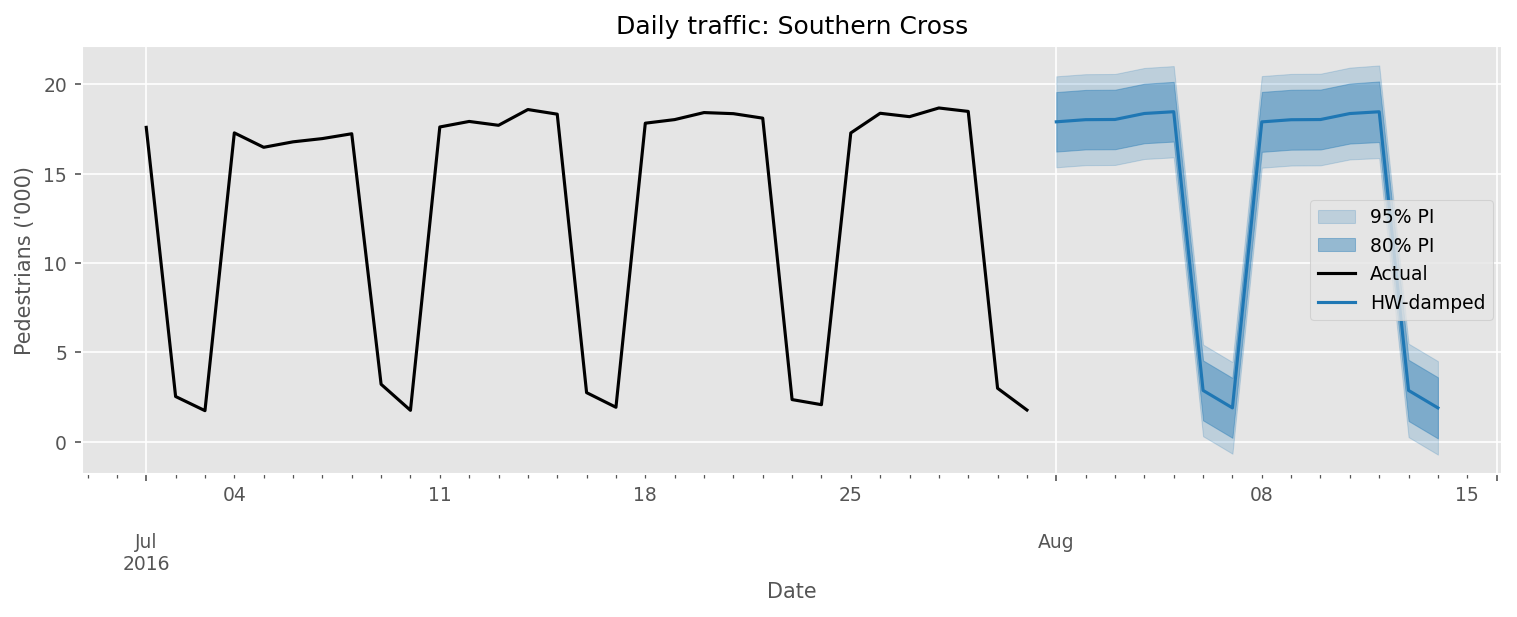

In [36]:
fig, ax = plt.subplots()
ax.fill_between(df_f["ds"], df_f['HW-Damped-lo-95'], df_f['HW-Damped-hi-95'], color='tab:blue', alpha = 0.2)
ax.fill_between(df_f["ds"], df_f['HW-Damped-lo-80'], df_f['HW-Damped-hi-80'], color='tab:blue', alpha = 0.4)
df_scross.plot(ax=ax, x='ds', y='y', color='black', legend=False)
df_f.plot(ax=ax, x='ds', y='HW-Damped', color='tab:blue', legend=False)
ax.set_title("Daily traffic: Southern Cross")
ax.set_xlabel("Date")
ax.set_ylabel("Pedestrians ('000)")
plt.legend(['95% PI', '80% PI', 'Actual', 'HW-damped'])
plt.autoscale()
plt.show()

## Taxonomy of exponential smoothing methods

A two-way classification of exponential smoothing methods:

<table class="do-not-create-environment cell caption-top table table-sm table-striped small">
<colgroup>
<col style="width: 21%">
<col style="width: 21%">
<col style="width: 25%">
<col style="width: 31%">
</colgroup>
<thead>
<tr class="header">
<th>Trend Component</th>
<th>Seasonal Component: N (None)</th>
<th>Seasonal Component: A (Additive)</th>
<th>Seasonal Component: M (Multiplicative)</th>
</tr>
</thead>
<tbody>
<tr class="odd">
<td>N (None)</td>
<td>(N,N)</td>
<td>(N,A)</td>
<td>(N,M)</td>
</tr>
<tr class="even">
<td>A (Additive)</td>
<td>(A,N)</td>
<td>(A,A)</td>
<td>(A,M)</td>
</tr>
<tr class="odd">
<td><span class="math inline"><span class="katex"><span class="katex-mathml"><math xmlns="http://www.w3.org/1998/Math/MathML"><semantics><mrow><msub><mi>A</mi><mi>d</mi></msub></mrow><annotation encoding="application/x-tex">A_d</annotation></semantics></math></span><span class="katex-html" aria-hidden="true"><span class="base"><span class="strut" style="height: 0.8333em; vertical-align: -0.15em;"></span><span class="mord"><span class="mord mathnormal">A</span><span class="msupsub"><span class="vlist-t vlist-t2"><span class="vlist-r"><span class="vlist" style="height: 0.3361em;"><span class="" style="top: -2.55em; margin-left: 0em; margin-right: 0.05em;"><span class="pstrut" style="height: 2.7em;"></span><span class="sizing reset-size6 size3 mtight"><span class="mord mathnormal mtight">d</span></span></span></span><span class="vlist-s">​</span></span><span class="vlist-r"><span class="vlist" style="height: 0.15em;"><span class=""></span></span></span></span></span></span></span></span></span></span> (Additive damped)</td>
<td><span class="math inline"><span class="katex"><span class="katex-mathml"><math xmlns="http://www.w3.org/1998/Math/MathML"><semantics><mrow><mo stretchy="false">(</mo><msub><mi>A</mi><mi>d</mi></msub><mo separator="true">,</mo><mi>N</mi><mo stretchy="false">)</mo></mrow><annotation encoding="application/x-tex">(A_d,N)</annotation></semantics></math></span><span class="katex-html" aria-hidden="true"><span class="base"><span class="strut" style="height: 1em; vertical-align: -0.25em;"></span><span class="mopen">(</span><span class="mord"><span class="mord mathnormal">A</span><span class="msupsub"><span class="vlist-t vlist-t2"><span class="vlist-r"><span class="vlist" style="height: 0.3361em;"><span class="" style="top: -2.55em; margin-left: 0em; margin-right: 0.05em;"><span class="pstrut" style="height: 2.7em;"></span><span class="sizing reset-size6 size3 mtight"><span class="mord mathnormal mtight">d</span></span></span></span><span class="vlist-s">​</span></span><span class="vlist-r"><span class="vlist" style="height: 0.15em;"><span class=""></span></span></span></span></span></span><span class="mpunct">,</span><span class="mspace" style="margin-right: 0.1667em;"></span><span class="mord mathnormal" style="margin-right: 0.109em;">N</span><span class="mclose">)</span></span></span></span></span></td>
<td><span class="math inline"><span class="katex"><span class="katex-mathml"><math xmlns="http://www.w3.org/1998/Math/MathML"><semantics><mrow><mo stretchy="false">(</mo><msub><mi>A</mi><mi>d</mi></msub><mo separator="true">,</mo><mi>A</mi><mo stretchy="false">)</mo></mrow><annotation encoding="application/x-tex">(A_d,A)</annotation></semantics></math></span><span class="katex-html" aria-hidden="true"><span class="base"><span class="strut" style="height: 1em; vertical-align: -0.25em;"></span><span class="mopen">(</span><span class="mord"><span class="mord mathnormal">A</span><span class="msupsub"><span class="vlist-t vlist-t2"><span class="vlist-r"><span class="vlist" style="height: 0.3361em;"><span class="" style="top: -2.55em; margin-left: 0em; margin-right: 0.05em;"><span class="pstrut" style="height: 2.7em;"></span><span class="sizing reset-size6 size3 mtight"><span class="mord mathnormal mtight">d</span></span></span></span><span class="vlist-s">​</span></span><span class="vlist-r"><span class="vlist" style="height: 0.15em;"><span class=""></span></span></span></span></span></span><span class="mpunct">,</span><span class="mspace" style="margin-right: 0.1667em;"></span><span class="mord mathnormal">A</span><span class="mclose">)</span></span></span></span></span></td>
<td><span class="math inline"><span class="katex"><span class="katex-mathml"><math xmlns="http://www.w3.org/1998/Math/MathML"><semantics><mrow><mo stretchy="false">(</mo><msub><mi>A</mi><mi>d</mi></msub><mo separator="true">,</mo><mi>M</mi><mo stretchy="false">)</mo></mrow><annotation encoding="application/x-tex">(A_d,M)</annotation></semantics></math></span><span class="katex-html" aria-hidden="true"><span class="base"><span class="strut" style="height: 1em; vertical-align: -0.25em;"></span><span class="mopen">(</span><span class="mord"><span class="mord mathnormal">A</span><span class="msupsub"><span class="vlist-t vlist-t2"><span class="vlist-r"><span class="vlist" style="height: 0.3361em;"><span class="" style="top: -2.55em; margin-left: 0em; margin-right: 0.05em;"><span class="pstrut" style="height: 2.7em;"></span><span class="sizing reset-size6 size3 mtight"><span class="mord mathnormal mtight">d</span></span></span></span><span class="vlist-s">​</span></span><span class="vlist-r"><span class="vlist" style="height: 0.15em;"><span class=""></span></span></span></span></span></span><span class="mpunct">,</span><span class="mspace" style="margin-right: 0.1667em;"></span><span class="mord mathnormal" style="margin-right: 0.109em;">M</span><span class="mclose">)</span></span></span></span></span></td>
</tr>
</tbody>
</table>

Some of these methods we have already seen using other names:

<div class="cell" data-execution_count="36">
<div id="tbl-shorthand" class="cell quarto-float quarto-figure quarto-figure-center anchored" data-execution_count="36">
<figure class="quarto-float quarto-float-tbl figure">
<div aria-describedby="tbl-shorthand-caption-0ceaefa1-69ba-4598-a22c-09a6ac19f8ca">
<div class="cell-output cell-output-display cell-output-markdown">
<table class="do-not-create-environment cell caption-top table table-sm table-striped small">
<thead>
<tr class="header">
<th>Short hand</th>
<th>Method</th>
</tr>
</thead>
<tbody>
<tr class="odd">
<td><span class="math inline"><span class="katex"><span class="katex-mathml"><math xmlns="http://www.w3.org/1998/Math/MathML"><semantics><mrow><mo stretchy="false">(</mo><mi>N</mi><mo separator="true">,</mo><mi>N</mi><mo stretchy="false">)</mo></mrow><annotation encoding="application/x-tex">(N,N)</annotation></semantics></math></span><span class="katex-html" aria-hidden="true"><span class="base"><span class="strut" style="height: 1em; vertical-align: -0.25em;"></span><span class="mopen">(</span><span class="mord mathnormal" style="margin-right: 0.109em;">N</span><span class="mpunct">,</span><span class="mspace" style="margin-right: 0.1667em;"></span><span class="mord mathnormal" style="margin-right: 0.109em;">N</span><span class="mclose">)</span></span></span></span></span></td>
<td>Simple exponential smoothing</td>
</tr>
<tr class="even">
<td><span class="math inline"><span class="katex"><span class="katex-mathml"><math xmlns="http://www.w3.org/1998/Math/MathML"><semantics><mrow><mo stretchy="false">(</mo><mi>A</mi><mo separator="true">,</mo><mi>N</mi><mo stretchy="false">)</mo></mrow><annotation encoding="application/x-tex">(A,N)</annotation></semantics></math></span><span class="katex-html" aria-hidden="true"><span class="base"><span class="strut" style="height: 1em; vertical-align: -0.25em;"></span><span class="mopen">(</span><span class="mord mathnormal">A</span><span class="mpunct">,</span><span class="mspace" style="margin-right: 0.1667em;"></span><span class="mord mathnormal" style="margin-right: 0.109em;">N</span><span class="mclose">)</span></span></span></span></span></td>
<td>Holt’s linear method</td>
</tr>
<tr class="odd">
<td><span class="math inline"><span class="katex"><span class="katex-mathml"><math xmlns="http://www.w3.org/1998/Math/MathML"><semantics><mrow><mo stretchy="false">(</mo><msub><mi>A</mi><mi>d</mi></msub><mo separator="true">,</mo><mi>N</mi><mo stretchy="false">)</mo></mrow><annotation encoding="application/x-tex">(A_d,N)</annotation></semantics></math></span><span class="katex-html" aria-hidden="true"><span class="base"><span class="strut" style="height: 1em; vertical-align: -0.25em;"></span><span class="mopen">(</span><span class="mord"><span class="mord mathnormal">A</span><span class="msupsub"><span class="vlist-t vlist-t2"><span class="vlist-r"><span class="vlist" style="height: 0.3361em;"><span class="" style="top: -2.55em; margin-left: 0em; margin-right: 0.05em;"><span class="pstrut" style="height: 2.7em;"></span><span class="sizing reset-size6 size3 mtight"><span class="mord mathnormal mtight">d</span></span></span></span><span class="vlist-s">​</span></span><span class="vlist-r"><span class="vlist" style="height: 0.15em;"><span class=""></span></span></span></span></span></span><span class="mpunct">,</span><span class="mspace" style="margin-right: 0.1667em;"></span><span class="mord mathnormal" style="margin-right: 0.109em;">N</span><span class="mclose">)</span></span></span></span></span></td>
<td>Additive damped trend method</td>
</tr>
<tr class="even">
<td><span class="math inline"><span class="katex"><span class="katex-mathml"><math xmlns="http://www.w3.org/1998/Math/MathML"><semantics><mrow><mo stretchy="false">(</mo><mi>A</mi><mo separator="true">,</mo><mi>A</mi><mo stretchy="false">)</mo></mrow><annotation encoding="application/x-tex">(A,A)</annotation></semantics></math></span><span class="katex-html" aria-hidden="true"><span class="base"><span class="strut" style="height: 1em; vertical-align: -0.25em;"></span><span class="mopen">(</span><span class="mord mathnormal">A</span><span class="mpunct">,</span><span class="mspace" style="margin-right: 0.1667em;"></span><span class="mord mathnormal">A</span><span class="mclose">)</span></span></span></span></span></td>
<td>Additive Holt-Winters’ method</td>
</tr>
<tr class="odd">
<td><span class="math inline"><span class="katex"><span class="katex-mathml"><math xmlns="http://www.w3.org/1998/Math/MathML"><semantics><mrow><mo stretchy="false">(</mo><mi>A</mi><mo separator="true">,</mo><mi>M</mi><mo stretchy="false">)</mo></mrow><annotation encoding="application/x-tex">(A,M)</annotation></semantics></math></span><span class="katex-html" aria-hidden="true"><span class="base"><span class="strut" style="height: 1em; vertical-align: -0.25em;"></span><span class="mopen">(</span><span class="mord mathnormal">A</span><span class="mpunct">,</span><span class="mspace" style="margin-right: 0.1667em;"></span><span class="mord mathnormal" style="margin-right: 0.109em;">M</span><span class="mclose">)</span></span></span></span></span></td>
<td>Multiplicative Holt-Winters’ method</td>
</tr>
<tr class="even">
<td><span class="math inline"><span class="katex"><span class="katex-mathml"><math xmlns="http://www.w3.org/1998/Math/MathML"><semantics><mrow><mo stretchy="false">(</mo><msub><mi>A</mi><mi>d</mi></msub><mo separator="true">,</mo><mi>A</mi><mo stretchy="false">)</mo></mrow><annotation encoding="application/x-tex">(A_d,A)</annotation></semantics></math></span><span class="katex-html" aria-hidden="true"><span class="base"><span class="strut" style="height: 1em; vertical-align: -0.25em;"></span><span class="mopen">(</span><span class="mord"><span class="mord mathnormal">A</span><span class="msupsub"><span class="vlist-t vlist-t2"><span class="vlist-r"><span class="vlist" style="height: 0.3361em;"><span class="" style="top: -2.55em; margin-left: 0em; margin-right: 0.05em;"><span class="pstrut" style="height: 2.7em;"></span><span class="sizing reset-size6 size3 mtight"><span class="mord mathnormal mtight">d</span></span></span></span><span class="vlist-s">​</span></span><span class="vlist-r"><span class="vlist" style="height: 0.15em;"><span class=""></span></span></span></span></span></span><span class="mpunct">,</span><span class="mspace" style="margin-right: 0.1667em;"></span><span class="mord mathnormal">A</span><span class="mclose">)</span></span></span></span></span></td>
<td>Holt-Winters’ damped method</td>
</tr>
</tbody>
</table>
</div>
</div>
</figure>
<a class="anchorjs-link external" aria-label="Anchor" data-anchorjs-icon="" href="#tbl-shorthand" style="font: 1em / 1 anchorjs-icons; margin-left: 0.1875em; padding-right: 0.1875em; padding-left: 0.1875em;"></a></div>
</div>

The methods above constitute the TS part of a class of methods called ETS (Error-Trend-Seasonality).

The summary of the formulas for the recursive equations can be found in [FPP3](https://otexts.com/fpp3/taxonomy.html).